## Read output files

In [4]:
import awkward as ak
import numpy as np
import uproot
import os
import pandas as pd

In [2]:
basedir = {
    'data': '../condor/output/data/2018/',
    'TTGJets': '../condor/output/mc/2018/TTGJets/',
    'ZJetsToQQ': '../condor/output/mc/2018/ZJetsToQQ/',
    'WJetsToQQ': '../condor/output/mc/2018/WJetsToQQ/',
    'GJets': '../condor/output/mc/2018/GJets/',
    'QCD': '../condor/output/mc/2018/QCD/',
    'ZpToHGamma': '../condor/output/mc/2018/ZpToHGamma/ZpToHGamma_M2000/',
}

filepath={c: [] for c in basedir}
for c in basedir:
    for (current_path, dirs, files) in os.walk(basedir[c]):
        for f in files:
            if f.endswith('.parq'):
                filepath[c].append(os.path.join(current_path, f))

filepath

{'data': ['../condor/output/data/2018/EGamma/EGamma_Run2018D/141.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/207.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/343.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/289.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/348.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/2.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/183.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/64.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/85.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/120.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/94.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/206.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/354.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/339.parq',
  '../condor/output/data/2018/EGamma/EGamma_Run2018D/237.parq',
  '../condor/output/data/2018/EGamma/

In [5]:
events = {
    k: [] for k in filepath
}
for k, v in filepath.items():
    for f in v:
        if os.path.getsize(f) == 0:
            print('Zero size:', f)
            continue
        if len(pd.read_parquet(f))==0:
            continue
        array = ak.from_parquet(f)
        if len(array)>0:
            events[k].append(array)
    events[k] = ak.concatenate(events[k], axis=0)

events

Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/348.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/2.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/120.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/19.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/55.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/21.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/26.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/41.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/351.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/350.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/295.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/40.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/37.parq
Zero size: ../condor/output/data/2018/EGamma/EGamma_Run2018D/54.parq
Zero size: ../condor/output/da

{'data': <Array [{heaviest_jet_msoftdrop: 105, ... ] type='377700 * {"heaviest_jet_msoftd...'>,
 'TTGJets': <Array [{heaviest_jet_msoftdrop: 221, ... ] type='2791 * {"heaviest_jet_msoftdro...'>,
 'ZJetsToQQ': <Array [{heaviest_jet_pt: 333, ... ] type='1121 * {"heaviest_jet_pt": ?float32, ...'>,
 'WJetsToQQ': <Array [{heaviest_jet_pt: 324, ... ] type='2870 * {"heaviest_jet_pt": ?float32, ...'>,
 'GJets': <Array [{heaviest_jet_mass: 61.6, ... ] type='207712 * {"heaviest_jet_mass": ?fl...'>,
 'QCD': <Array [{heaviest_jet_mass: 188, ... ] type='7437 * {"heaviest_jet_mass": ?float...'>,
 'ZpToHGamma': <Array [{heaviest_jet_phi: -2.53, ... ] type='13401 * {"heaviest_jet_phi": ?floa...'>}

In [122]:
BKG = set(events.keys()) - {'ZpToHGamma', 'data'}
BKG

{'GJets', 'QCD', 'TTGJets', 'WJetsToQQ', 'ZJetsToQQ'}

In [12]:
set(events['GJets'].event_weight)

{0.3364230538198739, 0.9716167001332726, 2.208680842345895}

## Decomposite signal

In [123]:
def decomposite(signal: ak.Array):
    HWW_decay_mode = ak.fill_none(signal['gen_HWW_decay_mode'], 0)
    decomposition = {}
    for tag in signal.fields:
        if tag.startswith('gen_Zp') and tag!='gen_ZpToHGamma':
            decomposition[tag.split('_')[1]] = signal[signal[tag]]
    
    decomposition['HWW_4q'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode >= 32)
    ]
    
    decomposition['HWW_qqlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode > 16) &
        (HWW_decay_mode < 32)
    ]
    
    decomposition['HWW_lvlv'] = signal[
        signal['gen_ZpToH(WW)Gamma'] & 
        (HWW_decay_mode <= 16)
    ]
    
    return decomposition

events.update(decomposite(events['ZpToHGamma']))
events

{'data': <Array [{heaviest_jet_phi: 1.67, ... ] type='110491 * {"heaviest_jet_phi": ?floa...'>,
 'TTGJets': <Array [{heaviest_jet_mass: 87.3, ... ] type='2905 * {"heaviest_jet_mass": ?floa...'>,
 'ZJetsToQQ': <Array [{heaviest_jet_pt: 300, ... ] type='1223 * {"heaviest_jet_pt": ?float32, ...'>,
 'WJetsToQQ': <Array [{heaviest_jet_mass: 92, ... ] type='3053 * {"heaviest_jet_mass": ?float3...'>,
 'GJets': <Array [{heaviest_jet_mass: 93, ... ] type='218744 * {"heaviest_jet_mass": ?floa...'>,
 'QCD': <Array [{heaviest_jet_eta: 0.78, ... ] type='8095 * {"heaviest_jet_eta": ?float3...'>,
 'ZpToHGamma': <Array [{heaviest_jet_mass: 136, ... ] type='13406 * {"heaviest_jet_mass": ?floa...'>,
 'ZpToH(WW)Gamma': <Array [{heaviest_jet_mass: 68.8, ... ] type='5294 * {"heaviest_jet_mass": ?floa...'>,
 'ZpToH(bb)Gamma': <Array [{heaviest_jet_mass: 136, ... ] type='3333 * {"heaviest_jet_mass": ?float...'>,
 'ZpToH(ZZ)Gamma': <Array [{heaviest_jet_mass: 119, ... ] type='501 * {"heaviest_jet_mass": ?floa

## Start plotting

In [124]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['cyan', 'darkorange', 'HotPink', 'darkviolet', 'SlateGray', 'red', 'blue', 'green', 'black', 'LightSkyBlue'])

In [125]:
set(events['ZpToHGamma'].event_genWeight)

{-1.0, -0.9900000095367432, 0.9800999760627747, 0.9900000095367432, 1.0}

In [126]:
weight={k: events[k].event_weight for k in events if k!='data'}

In [127]:
def flow(hist: bh.Histogram, overflow: bool=True, underflow: bool=False):
    h, var = hist.view(flow=(overflow|underflow)).value, hist.view(flow=(overflow|underflow)).variance
    if overflow: ## h, var also include underflow bins but in plots usually no underflow data
        ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
        h[-2]+=h[-1]; var[-2]+=var[-1]
    if underflow:
        h[1]+=h[0]; var[1]+=var[0]
    if overflow or underflow:
        h = h[1:-1]; var = var[1:-1]
    return h, var
    
def plot(arrays, weight, plot_name: str, x_name: str, cuts=None, year=2018, bins=40, x_min=0, x_max=2000, density=False, overflow=True, underflow=False):
    bin_width = (x_max-x_min)/bins
    color={'ZpToHGamma': 'red', 'ZpToH(WW)Gamma': 'blue', 'ZpToH(bb)Gamma': 'green', 'ZpToH(ZZ)Gamma': 'hotpink', 'ZpToH(tautau)Gamma': 'LightSkyBlue'}
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    # f, ax = plt.subplots()
    f = plt.figure(figsize=(9,9))
    gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.1)
    ax = f.add_subplot(gs[0])
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax, lumi=59.83, fontsize=18)
    ## Ratio panel
    ax1 = f.add_subplot(gs[1]); 
    ax1.grid()
    
    ## analyze
    bkg = {'h': {}, 'var': {}}
    sig = {'h': {}, 'var': {}}
    
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if 'delta_phi' in plot_name:
            values = np.min([v, 2*np.pi-v], axis=0)
        values = ak.fill_none(v, -999)
        
        if k!='data' and k in color:
            hist.fill(values, weight=weight[k])
        else:
            hist.fill(values)
        h, var = flow(hist=hist, overflow=overflow, underflow=underflow)
        if k in BKG: 
            bkg['h'][k] = h
            bkg['var'][k] = var
        elif k=='data' or k in color:
            sig['h'][k] = h
            sig['var'][k] = var
        
    ## plot
    ax1.plot([x_min,x_max], [1,1], 'black')
    # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 
    hep.histplot(list(bkg['h'].values()), bins=hist.axes[0].edges, label=list(bkg['h'].keys()), histtype='fill', density=density, stack=True, linewidth=2, ax=ax)
    bkg_h = np.sum(list(bkg['h'].values()), axis=0)
    bkg_var = np.sum(list(bkg['var'].values()), axis=0)
    for (k,v) in sig['h'].items():
        if k=='data':
            hep.histplot(v, bins=hist.axes[0].edges, yerr=np.sqrt(sig['var'][k]), label=k, color='black', histtype='errorbar', density=density, stack=False, ax=ax)
            continue
        hep.histplot(v*100, bins=hist.axes[0].edges, yerr=np.sqrt(sig['var'][k]*100), label=k+r'$\times 100$', color=color[k], histtype='step', density=density, stack=False, linewidth=2, ax=ax)
        y = v/np.sqrt(bkg_h+1)
        yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
        hep.histplot(y, bins=hist.axes[0].edges, xerr=bin_width/2, yerr=yerr, label=k, histtype='errorbar', density=density, stack=True, ax=ax1, color=color[k])

    ## axises
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, ax.get_ylim()[1]*1.2)
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.tick_params(axis='both', which='major', labelsize=16)
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        ax.set_ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        ax.set_ylabel('A.U.', fontsize=20, ha='right', y=1)
    ax1.set_xlabel(x_name, fontsize=22, ha='right', x=1)
    ax1.set_ylabel(r'$S/\sqrt{B+1}$', ha='center', fontsize=20)
    ax1.set_xlim(x_min,x_max)
    ax1.set_ylim(0, 3)
    ax1.ticklabel_format(useOffset=False, style='plain')
    #ax1.set_yscale('log')
    ax1.tick_params(axis='both', which='major', labelsize=16)

    plt.xticks(size=16)
    plt.yticks(size=16)

    ## title, text and legend
    # plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    ax.legend(loc="best", ncol=2, frameon=False, fontsize=16)
    # plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')

    ## finalizing
    suffix = '_AU' if density else ''
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+plot_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [128]:
print(events['ZpToHGamma'].fields)
events.keys()

['heaviest_jet_mass', 'heaviest_jet_msoftdrop', 'heaviest_jet_pt', 'heaviest_jet_eta', 'heaviest_jet_phi', 'leading_photon_pt', 'leading_photon_eta', 'leading_photon_phi', 'leading_photon_mass', 'event_MET_pt', 'event_genWeight', 'photon-jet_pt', 'photon-jet_eta', 'photon-jet_phi', 'photon-jet_mass', 'photon-jet_deltaR', 'gen_ZpToHGamma', 'gen_ZpToH(WW)Gamma', 'gen_ZpToH(bb)Gamma', 'gen_ZpToH(ZZ)Gamma', 'gen_ZpToH(tautau)Gamma', 'gen_ZpToH(gammagamma)Gamma', 'gen_HWW_decay_mode', 'event_weight']


dict_keys(['data', 'TTGJets', 'ZJetsToQQ', 'WJetsToQQ', 'GJets', 'QCD', 'ZpToHGamma', 'ZpToH(WW)Gamma', 'ZpToH(bb)Gamma', 'ZpToH(ZZ)Gamma', 'ZpToH(tautau)Gamma', 'ZpToH(gammagamma)Gamma', 'HWW_4q', 'HWW_qqlv', 'HWW_lvlv'])

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

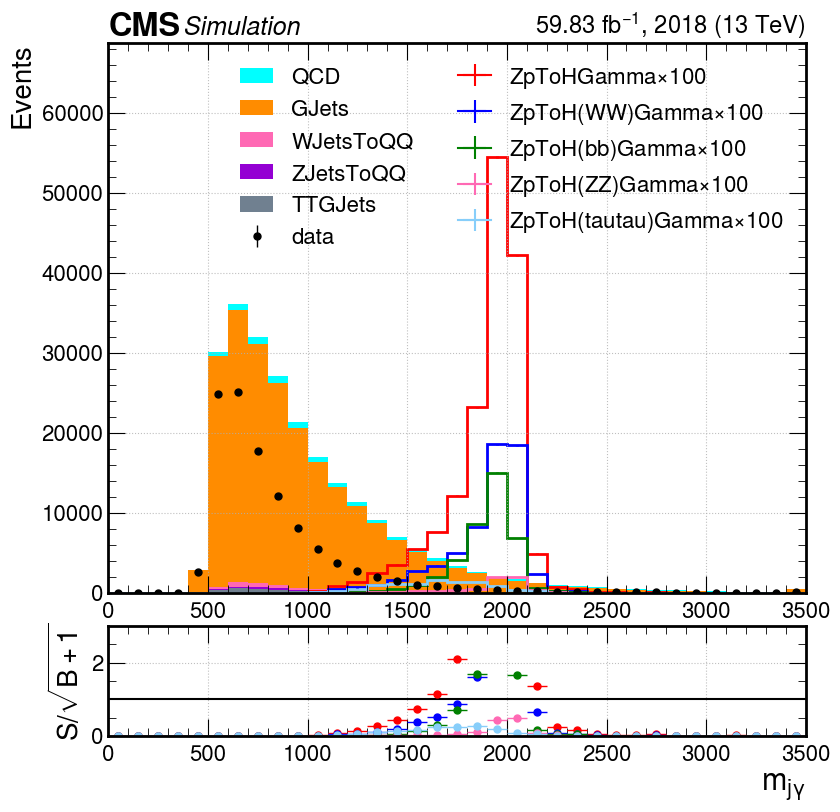

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


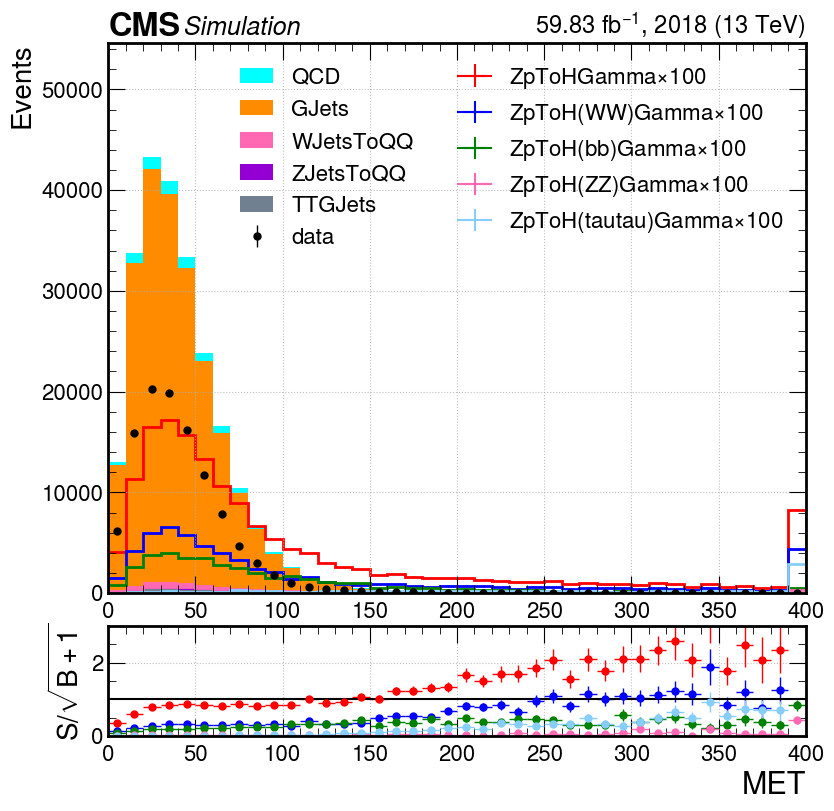

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

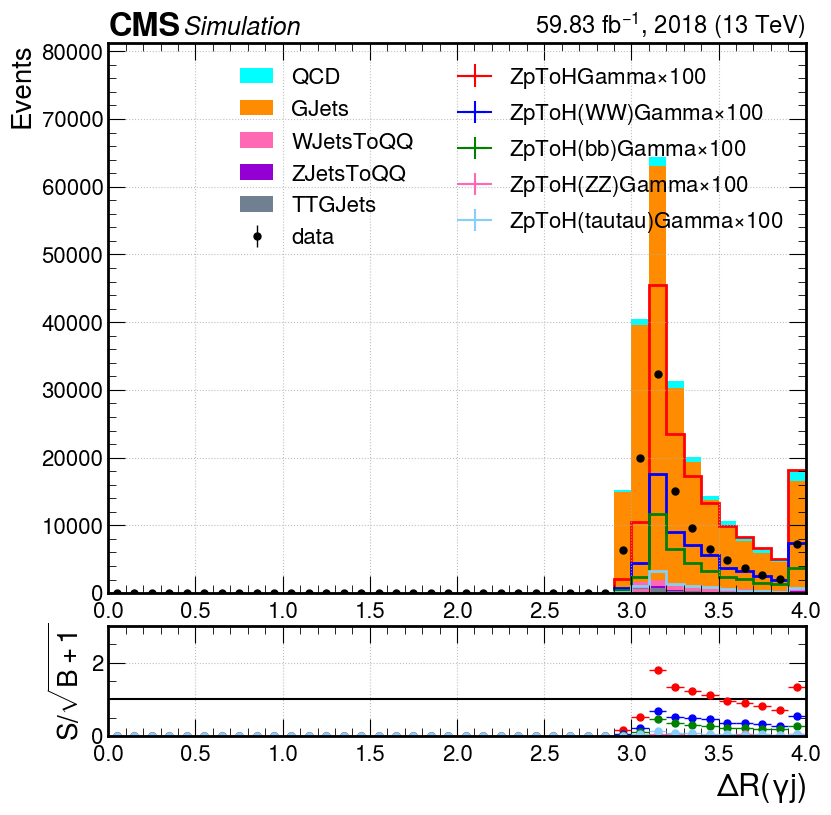

In [129]:
arrays={k: events[k]['photon-jet_mass'] for k in events}
plot(arrays, x_name=r'$m_{j\gamma}$', plot_name='photon-jet_mass', x_max=3500, bins=35, weight=weight)
arrays={k: events[k]['event_MET_pt'] for k in events}
plot(arrays, x_name='MET', plot_name='event_MET_pt', x_max=400, bins=40, weight=weight)
arrays={k: events[k]['photon-jet_deltaR'] for k in events}
plot(arrays, x_name=r'$\Delta R(\gamma j)$', plot_name='photon-jet_deltaR', x_max=4, bins=40, weight=weight)

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

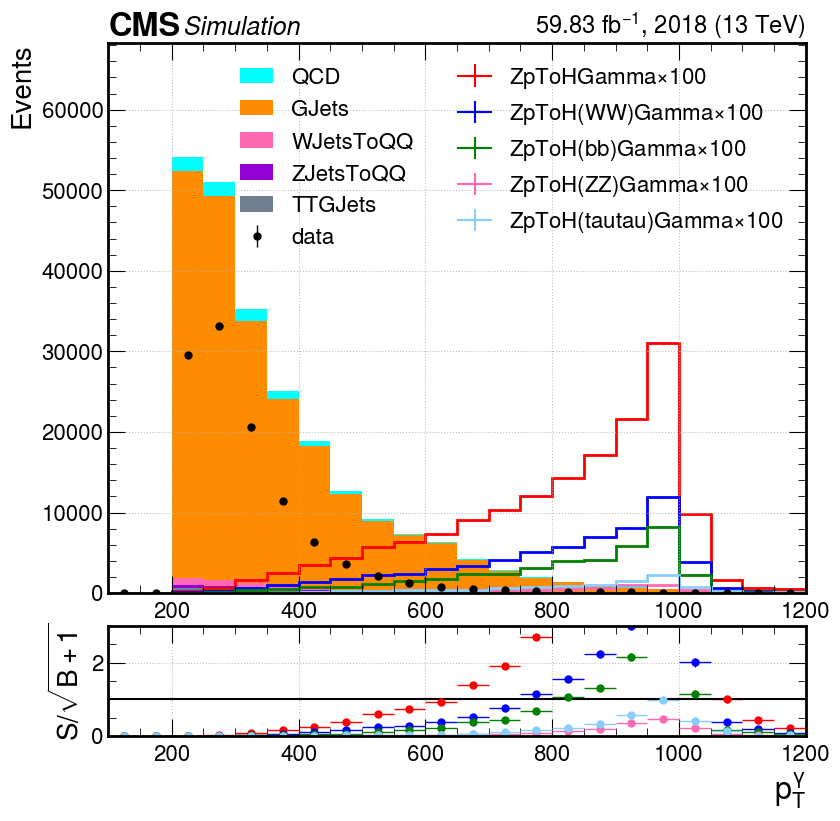

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

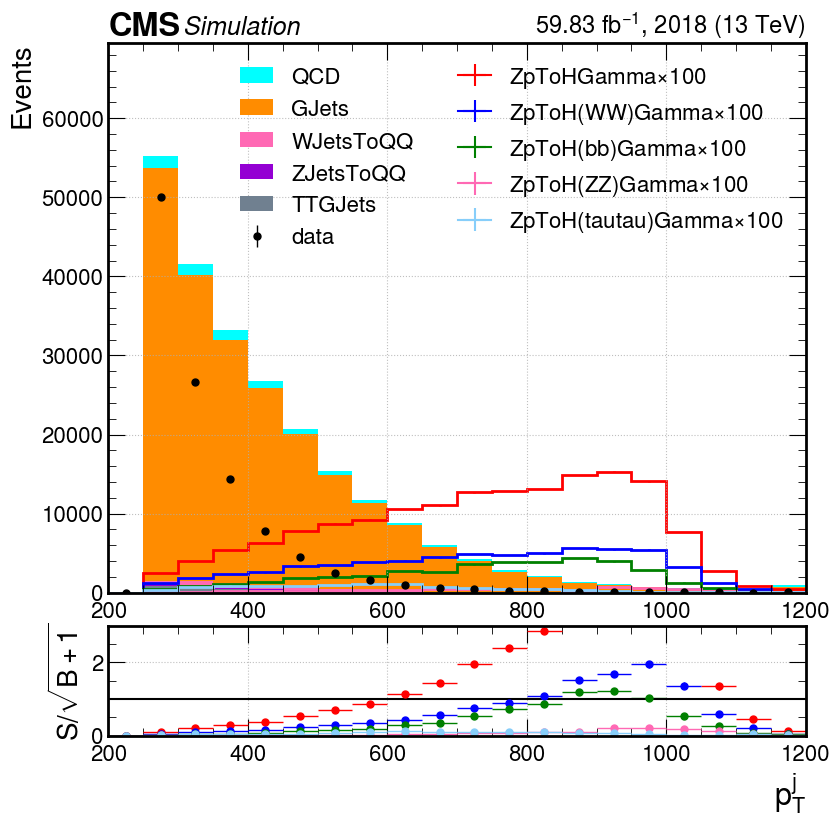

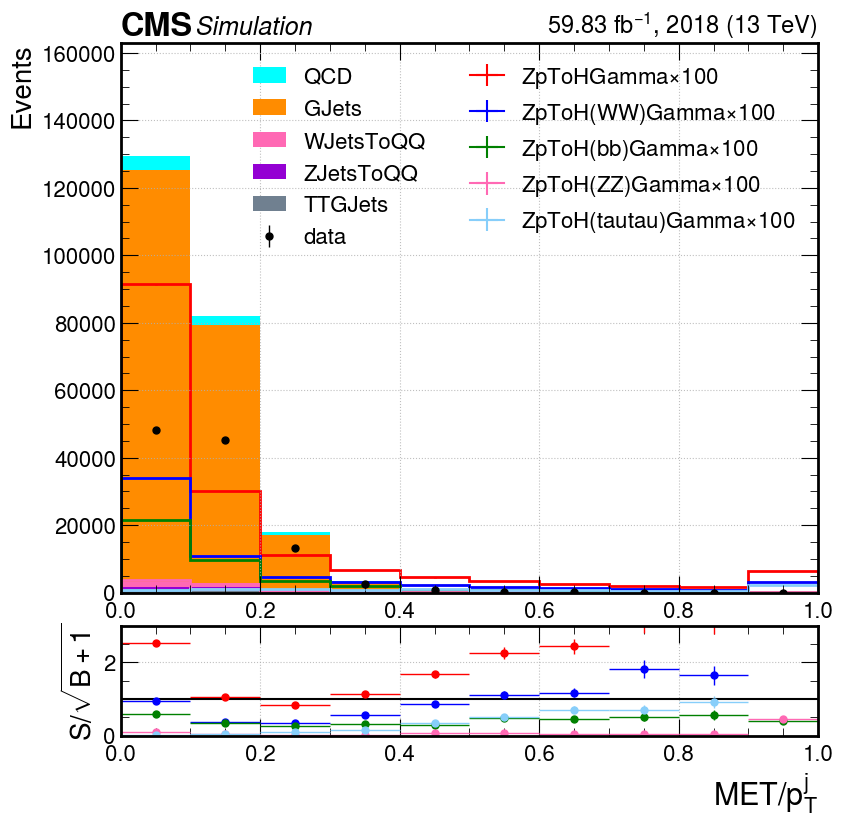

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

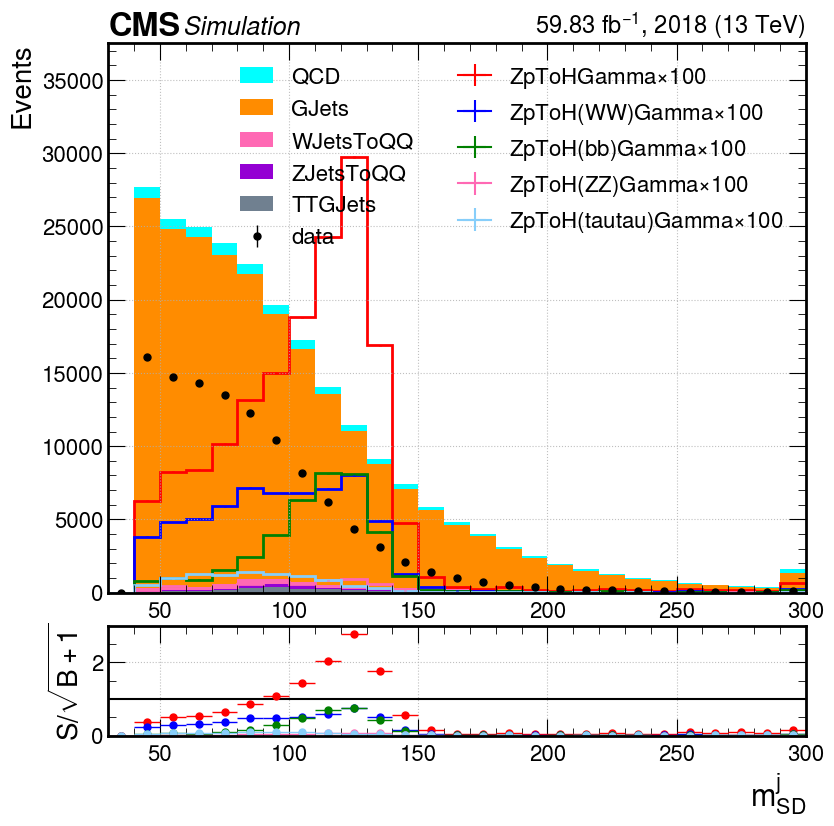

In [130]:
#leading_photon = {k: ak.argmax(events[k].leading_photon_pt, axis=1, keepdims=True) for k in events}
#heaviest_AK8jet = {k: ak.argmax(events[k].heaviest_jet_msoftdrop, axis=1, keepdims=True) for k in events}

arrays={k: events[k].leading_photon_pt for k in events}
plot(arrays, plot_name='photon_pt', x_name=r'$p_T^{\gamma}$', x_max=1200, x_min=100, bins=22, weight=weight)
arrays={k: events[k].heaviest_jet_pt for k in events}
plot(arrays, plot_name='AK8jet_pt', x_name=r'$p_T^{j}$', x_max=1200, x_min=200, bins=20, weight=weight)
arrays={k: events[k].event_MET_pt/events[k].heaviest_jet_pt for k in events}
plot(arrays, plot_name='MET_over_AK8jet_pt', x_name=r'$MET/p_T^{j}$', x_max=1, x_min=0, bins=10, weight=weight)
arrays={k: events[k].heaviest_jet_msoftdrop for k in events}
plot(arrays, plot_name='AK8jet_msoftdrop', x_name=r'$m_{SD}^{j}$', x_max=300, x_min=30, bins=27, weight=weight)

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: divide by zero encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in

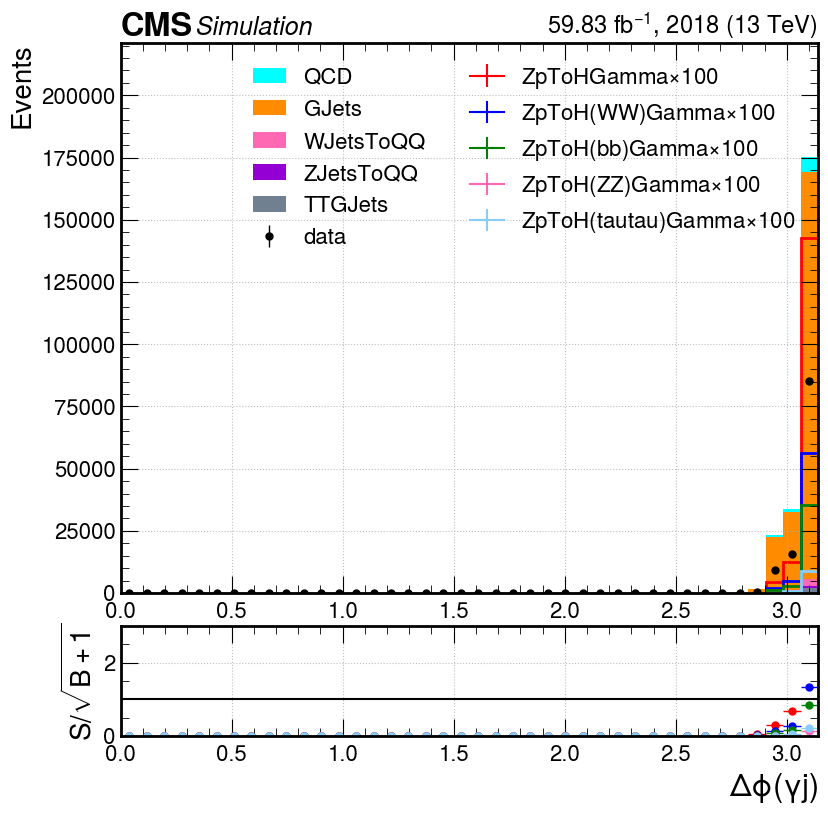

/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)
/tmp/ipykernel_2986553/3478583499.py:65: RuntimeWarning: invalid value encountered in true_divide
  yerr = y*np.sqrt(sig['var'][k]/(v**2) + 0.25/bkg_h)


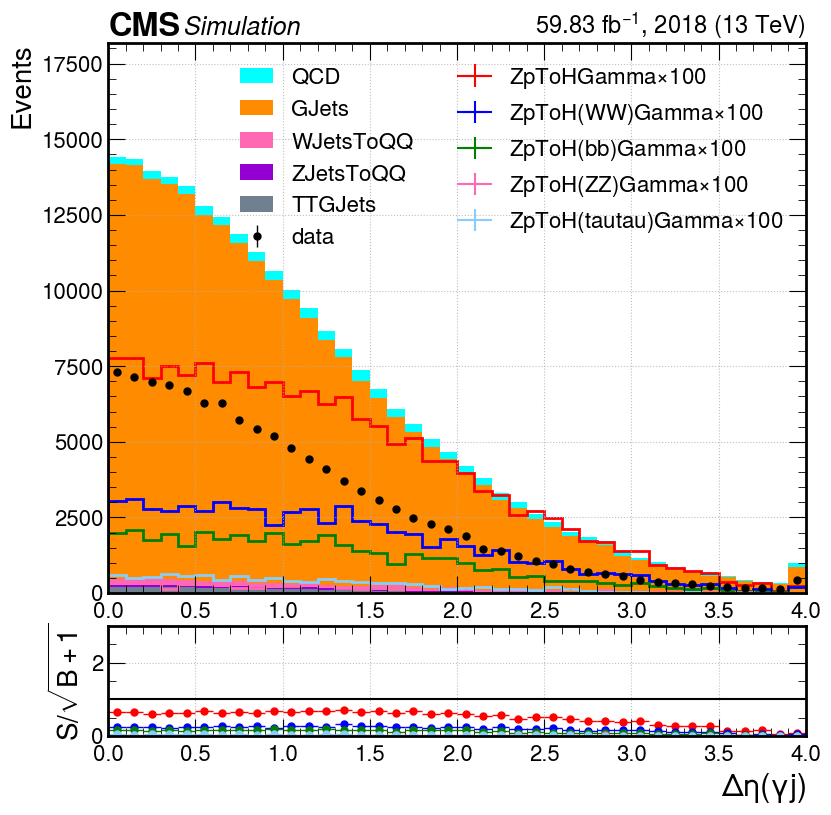

In [131]:
arrays={k: abs(events[k].leading_photon_phi - events[k].heaviest_jet_phi) for k in events}
plot(arrays, plot_name='photon-jet_delta_phi', x_name=r'$\Delta \phi(\gamma j)$', x_max=np.pi, bins=40, weight=weight)
arrays={k: abs(events[k].leading_photon_eta - events[k].heaviest_jet_eta) for k in events}
plot(arrays, plot_name='photon-jet_delta_eta', x_name=r'$\Delta \eta(\gamma j)$', x_max=4, bins=40, weight=weight)